In [27]:
from data_readers.polar_ppg_reader import read_polar_ppg_csv

import pandas as pd
import matplotlib.pyplot as plt

# Define the start and end times
start_time = '2025-08-08 15:43:00'
end_time = '2025-08-08 15:50:30'

In [30]:
polar_data = read_polar_ppg_csv('data/Polar_full_2025-08-08_15-42-06__to__2025-08-08_15-50-52.csv')
polar_data = polar_data[~polar_data['PPG0'].isna()]
polar_ms_diff = 43494.767
polar_data.index = polar_data.index + pd.Timedelta(milliseconds=polar_ms_diff)
polar_data = polar_data[(polar_data.index >= start_time) & (polar_data.index <= end_time)]
polar_data['PPG0'] .to_csv('polar_time_corrected.csv')
polar_data['PPG0_normalized'] = (polar_data['PPG0'] - polar_data['PPG0'].mean()) / polar_data['PPG0'].std()

In [32]:
galaxy_data = pd.read_pickle('data/concatenated_green_ppg_08.08.25.pkl')
galaxy_data = galaxy_data.set_index('datetime')
galaxy_ms_diff = 42623.50
galaxy_data.index = galaxy_data.index + pd.Timedelta(milliseconds=galaxy_ms_diff)
galaxy_data = galaxy_data[(galaxy_data.index >= start_time) & (galaxy_data.index <= end_time)]
galaxy_data.to_csv('galaxy_time_corrected.csv')
galaxy_data['ppg_green_value_normalized'] = (galaxy_data['ppg_green_value'] - galaxy_data['ppg_green_value'].mean()) / galaxy_data['ppg_green_value'].std()

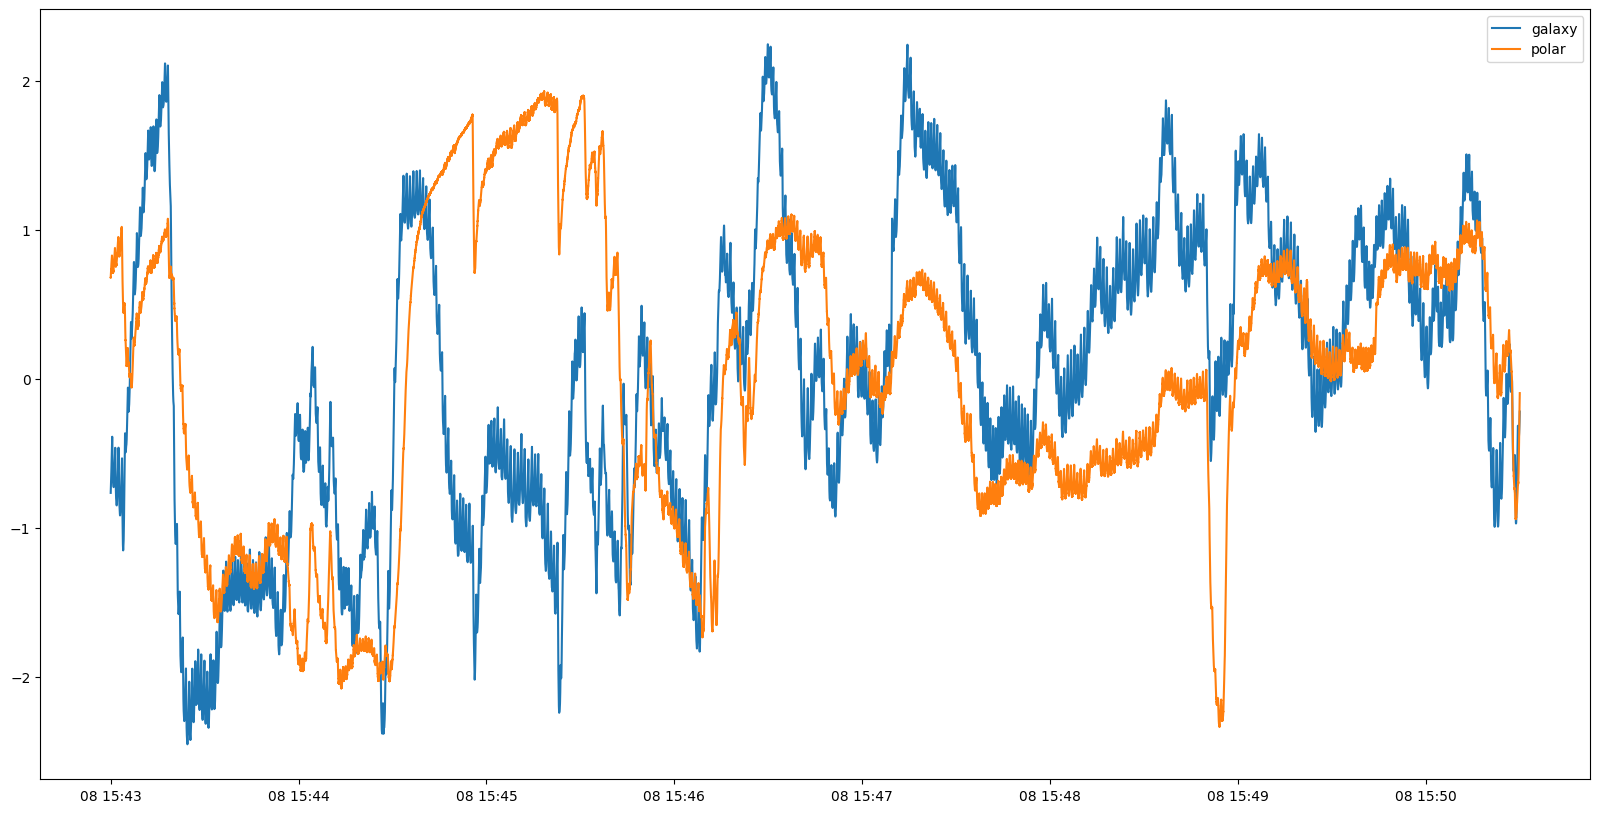

In [25]:
plt.figure(figsize=[20, 10])
plt.plot(galaxy_data['ppg_green_value_normalized'], label="galaxy")
plt.plot(polar_data['PPG0_normalized'], label="polar")
plt.legend()